## "Estratégia de Expansão em LA: Análise de Viabilidade de Cafetarias Automatizadas via Data Analytics"

### Configuração do Ambiente e Preparação de Dados

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

In [23]:
df=pd.read_csv('/content/rest_data_us_upd (1).csv')

In [24]:
df.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB


In [26]:
df.describe()

,id,number
count,9651.000000,9651.000000
mean,16611.000000,43.695161
std,2786.148058,47.622874
min,11786.000000,1.000000
25%,14198.500000,14.000000
50%,16611.000000,27.000000
75%,19023.500000,46.000000
max,21436.000000,229.000000


In [27]:
def executa_limpeza(df_input):
    """
    Pipeline de Limpeza seguindo o Protocolo de Data Analytics.
    """
    # 1. Cópia de Segurança
    df = df_input.copy()

    # 2. Padronização de Strings
    df['object_name'] = df['object_name'].str.strip().str.upper()
    df['object_type'] = df['object_type'].str.strip().str.lower()
    df['address'] = df['address'].str.strip().str.upper()

    # 3. Tratamento da Coluna 'Chain'
    chain_mapping = {
        True: True, False: False,
        'True': True, 'False': False,
        'TRUE': True, 'FALSE': False,
        't': True, 'f': False
    }
    df['chain'] = df['chain'].map(chain_mapping)

    # 4. Tratamento de Nulos
    df = df.dropna(subset=['chain'])

    # 5. Remoção de Duplicados
    antes = len(df)
    df = df.drop_duplicates(subset=['object_name', 'address']) # <-- O parêntese é obrigatório aqui
    depois = len(df)

    # Converter tipos
    df['chain'] = df['chain'].astype(bool)

    print(f"✅ Limpeza concluída!")
    print(f"   - Linhas originais: {len(df_input)}")
    print(f"   - Nulos removidos em 'chain': {len(df_input) - antes}")
    print(f"   - Duplicados removidos: {antes - depois}")
    print(f"   - Total final no df_limpo: {len(df)}")

    return df

# Execução
df_limpo = executa_limpeza(df)

✅ Limpeza concluída!
   - Linhas originais: 9651
   - Nulos removidos em 'chain': 3
   - Duplicados removidos: 1
   - Total final no df_limpo: 9647


In [28]:
# --- CHECKLIST DE INTEGRIDADE  ---

def check_dados_final(df):
    print("=== 🔍 RELATÓRIO DE AUDITORIA FINAL ===\n")

    # 1. Verificar de Nulos
    print(f"1. Valores Nulos:\n{df.isnull().sum()}\n")

    # 2. Verificar de Dtypes (Tipos de Dados)
    print(f"2. Tipos de Dados:\n{df.dtypes}\n")

    # 3. Validar a Coluna 'Chain' (O ponto crítico)
    print(f"3. Distribuição da Coluna Chain (Deve ser booleana):")
    print(df['chain'].value_counts())
    print(f"Tipo da coluna chain: {df['chain'].dtype}\n")

    # 4. Verificar de Duplicados
    duplicados = df.duplicated().sum()
    print(f"4. Linhas 100% duplicadas: {duplicados}\n")

    # 5. Consistência de Texto
    minusc_count = df[df['object_name'].str.contains(r'[a-z]', na=False)].shape[0]
    print(f"5. Nomes com letras minúsculas (Deveria ser 0): {minusc_count}")

# Executar a validação
check_dados_final(df_limpo)

=== 🔍 RELATÓRIO DE AUDITORIA FINAL ===

1. Valores Nulos:
id             0
object_name    0
address        0
chain          0
object_type    0
number         0
dtype: int64

2. Tipos de Dados:
id              int64
object_name    object
address        object
chain            bool
object_type    object
number          int64
dtype: object

3. Distribuição da Coluna Chain (Deve ser booleana):
chain
False    5972
True     3675
Name: count, dtype: int64
Tipo da coluna chain: bool

4. Linhas 100% duplicadas: 0

5. Nomes com letras minúsculas (Deveria ser 0): 0


### Tratamento de Outliers e Definição do Mercado Alvo

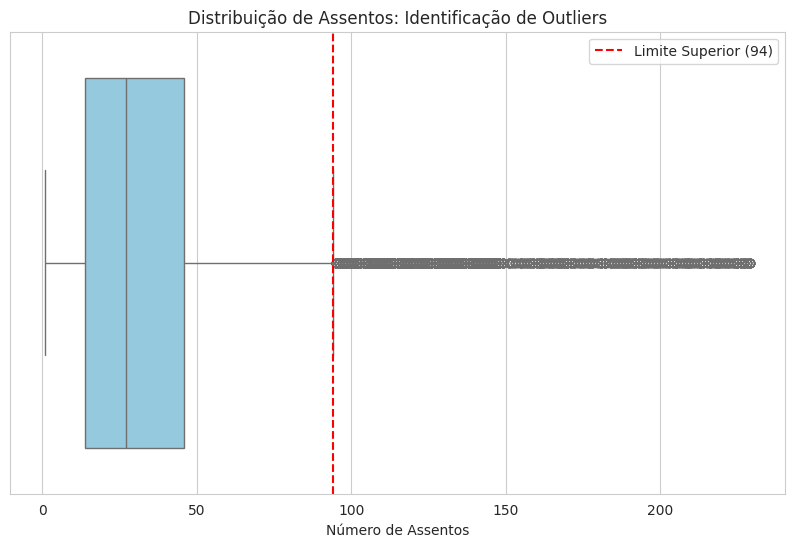

In [42]:

# 1. Configurar o tamanho do gráfico
plt.figure(figsize=(10, 6))

# 2. Criar o Boxplot para a coluna 'number'
sns.boxplot(x=df_limpo['number'], color='skyblue')

# 3. Adicionar linha do limite superior
plt.axvline(94, color='red', linestyle='--', label='Limite Superior (94)')

# 4. Títulos e Legendas
plt.title('Distribuição de Assentos: Identificação de Outliers')
plt.xlabel('Número de Assentos')
plt.legend()

plt.show()

In [30]:
# --- TRATAMENTO DE OUTLIERS ---

# 1. Quartis (25% e 75%)
Q1 = df_limpo['number'].quantile(0.25)
Q3 = df_limpo['number'].quantile(0.75)
IQR = Q3 - Q1

# 2.Limite superior (Regra clássica: Q3 + 1.5 * IQR)
limite_superior = Q3 + 1.5 * IQR

# 3. dataset de decisão (df_estrategia)
df_estrategia = df_limpo[df_limpo['number'] <= limite_superior].copy()

print(f"Limite superior estatístico: {limite_superior:.0f} lugares")
print(f"Outliers removidos: {len(df_limpo) - len(df_estrategia)} estabelecimentos gigantes")

Limite superior estatístico: 94 lugares
Outliers removidos: 1415 estabelecimentos gigantes


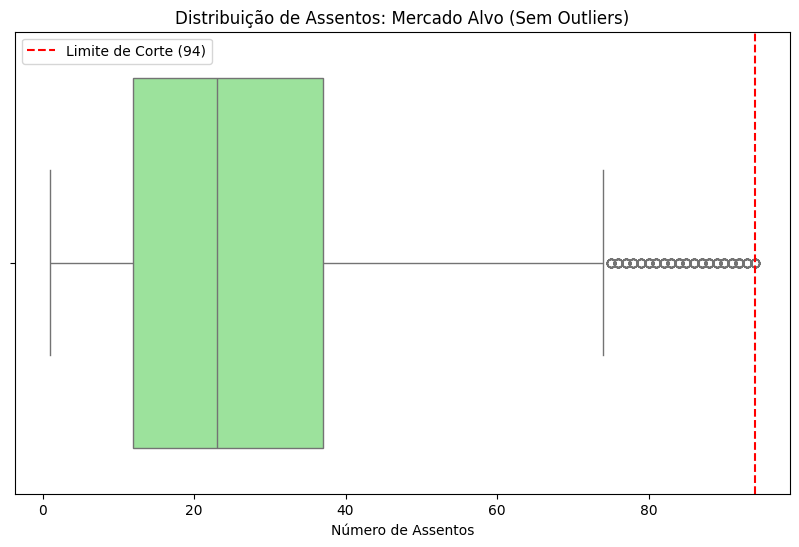

In [31]:

# --- GRÁFICO PÓS-FILTRAGEM  ---

# 1.  tamanho do gráfico
plt.figure(figsize=(10, 6))

# 2. Criar o Boxplot usando o DataFrame filtrado (df_estrategia)

sns.boxplot(x=df_estrategia['number'], color='lightgreen')

# 3. Adicionar a linha do limite (opcional, apenas para mostrar onde foi o corte)
plt.axvline(94, color='red', linestyle='--', label='Limite de Corte (94)')

# 4. Títulos e Legendas
plt.title('Distribuição de Assentos: Mercado Alvo (Sem Outliers)')
plt.xlabel('Número de Assentos')
plt.legend()

plt.show()

### Análise de Outliers

Os outliers foram identificados utilizando o método IQR e visualizados através de um boxplot.

Observa-se a presença de estabelecimentos com grande número de assentos. No entanto, esses valores representam negócios reais (como restaurantes de grande porte) e não erros nos dados.

Por isso, os outliers não foram removidos, garantindo que a análise represente fielmente o mercado.

#  Análise Exploratória e Validação Estatística de Mercado

/tmp/ipykernel_3519/3375970862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


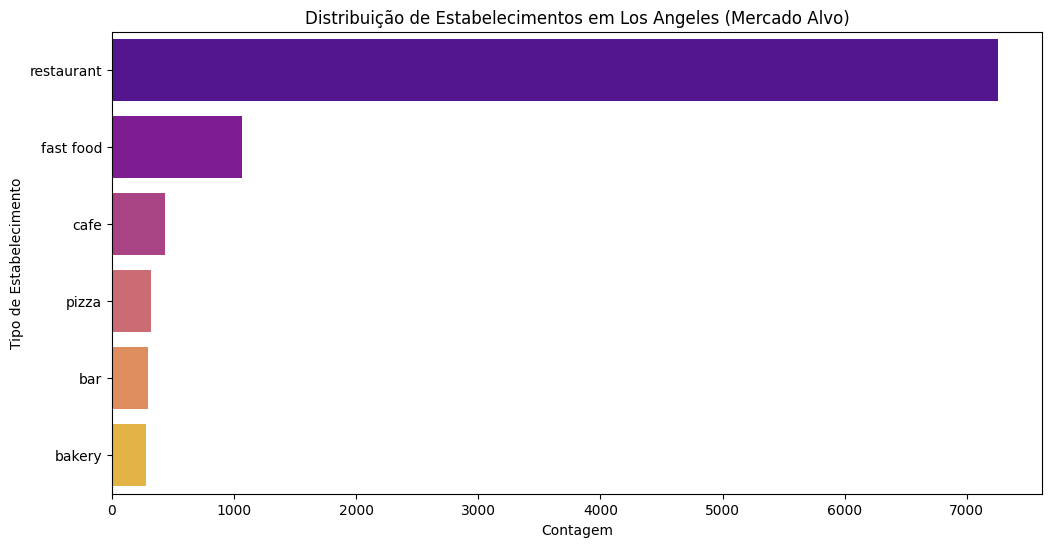

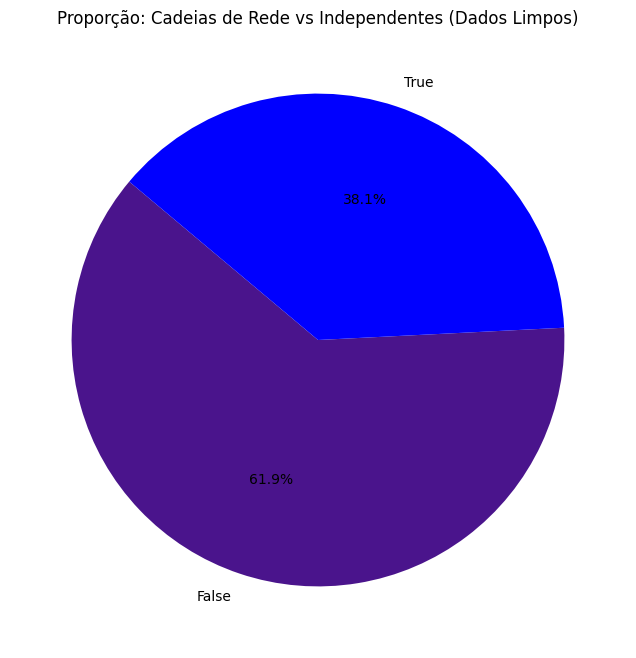

In [32]:


# --- EDA: Distribuição e Proporções ---

# 1. Ver a distribuição de tipos de estabelecimentos
plt.figure(figsize=(12, 6))
# Ajustado para df_limpo
sns.countplot(
    data=df_limpo,
    y='object_type',
    order=df_limpo['object_type'].value_counts().index,
    palette='plasma'
)
plt.title('Distribuição de Estabelecimentos em Los Angeles (Mercado Alvo)')
plt.xlabel('Contagem')
plt.ylabel('Tipo de Estabelecimento')
plt.show()

# 2. Ver a relação entre Redes e Independente
plt.figure(figsize=(8, 8))
df_limpo['chain'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#4A148C', 'blue'],
    startangle=140
)
plt.title('Proporção: Cadeias de Rede vs Independentes (Dados Limpos)')
plt.ylabel('') # Remove o label vertical para estética
plt.show()




### Insight

A predominância de estabelecimentos dos tipos *Restaurant* e *Fast Food* aponta para um mercado maduro e altamente diversificado. Ainda assim, o volume relevante de *Cafes* reforça um sinal importante: existe uma procura já consolidada para este formato.

Na prática, isto sugere que o consumo de café fora de casa não é um comportamento emergente, mas sim um hábito integrado no quotidiano urbano — algo consistente com tendências mais amplas, onde uma parte significativa do consumo ocorre fora do lar

 Conclusão: o mercado não precisa de ser educado — já existe adoção. O desafio passa por diferenciação e execução.

 ## Proporção de Redes vs Independentes

A análise mostra que aproximadamente 38% dos estabelecimentos pertencem a redes, enquanto cerca de 62% são independentes.

Isso indica que:

- O mercado não é dominado por grandes cadeias
- Há uma forte presença de negócios independentes
- Existe espaço para novos entrantes

Ao mesmo tempo, a participação significativa de redes demonstra que esse modelo de negócio é viável e escalável.

Portanto, o mercado apresenta um equilíbrio saudável entre independentes e cadeias, favorecendo tanto inovação quanto expansão em rede.

--- Iniciando EDA de Capacidade ---


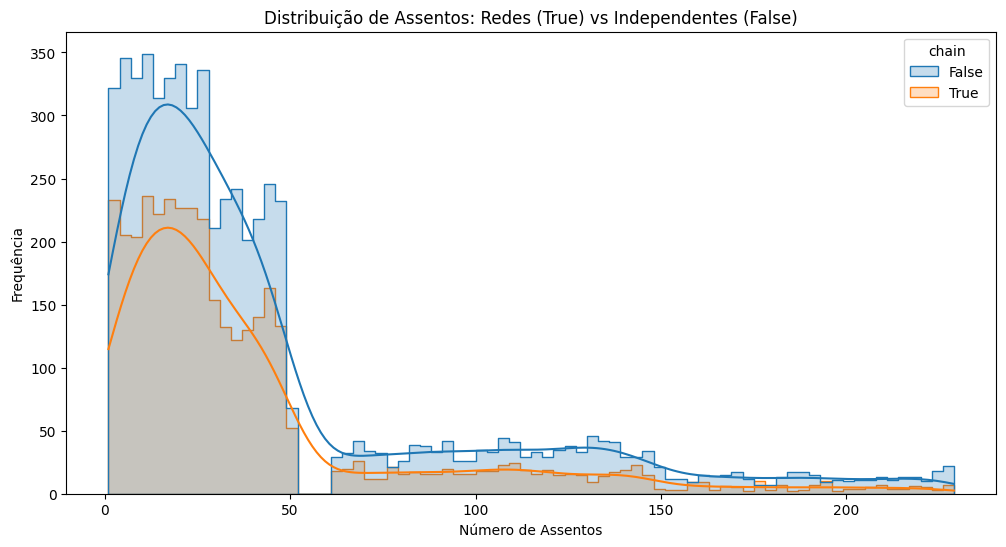

In [33]:
def analise_distribuicao(df_limpo):
    print("--- Iniciando EDA de Capacidade ---")

    # 1. Comparação de Médias por Tipo e Rede
    # Agrupar para entender o peso das redes no mercado
    resumo_negocio = df_limpo.groupby(['object_type', 'chain'])['number'].mean().unstack()

    # 2. Visualizar a Distribuição (Histograma + KDE)
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_limpo, x='number', hue='chain', kde=True, element="step")
    plt.title('Distribuição de Assentos: Redes (True) vs Independentes (False)')
    plt.xlabel('Número de Assentos')
    plt.ylabel('Frequência')
    plt.show()

    return resumo_negocio


stats_negocio = analise_distribuicao(df_limpo)



### Insight

Apesar da forte presença de grandes cadeias, a proporção significativa de estabelecimentos independentes revela um mercado longe de ser monopolizado.

Este equilíbrio competitivo é um sinal positivo:
- Existe abertura para novos entrantes  
- O consumidor não está preso a marcas dominantes  
- Há espaço para diferenciação real

👉 Em termos estratégicos, isto valida a entrada de um conceito inovador (como um café robótico), onde a vantagem não será escala inicial, mas sim proposta de valor e execução.

Conclusão: o mercado permite competir — mas não perdoa falta de posicionamento claro.

/tmp/ipykernel_3519/1038529643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


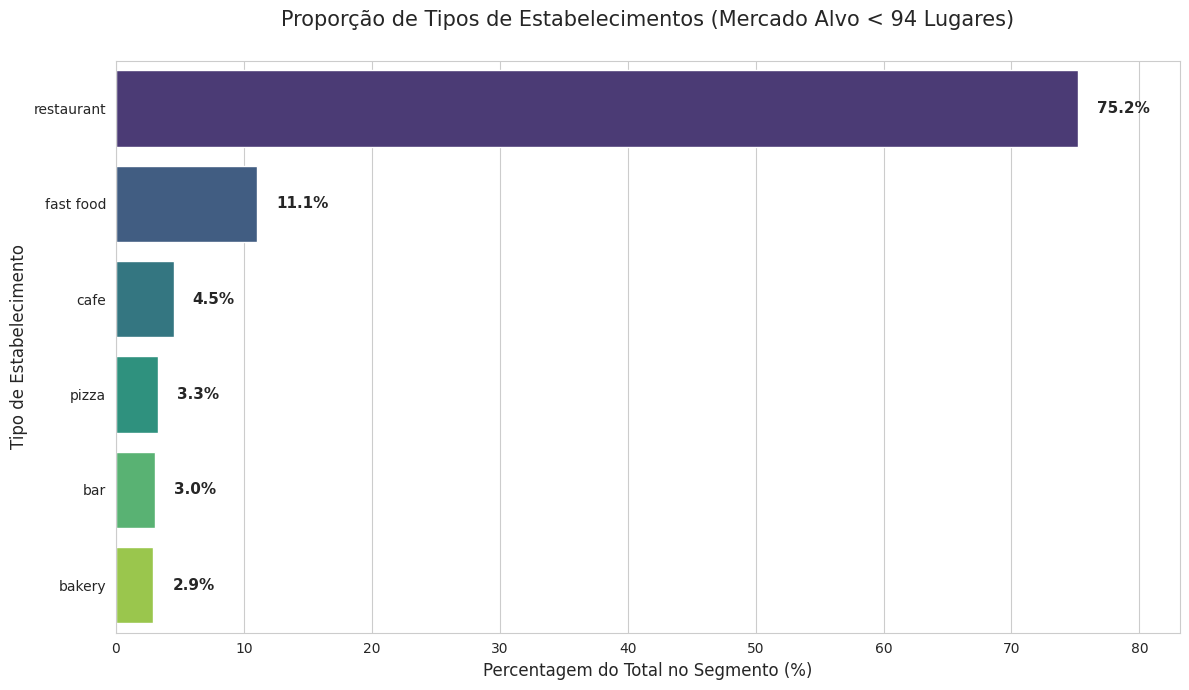

In [34]:
def plot_establishment_proportions(df_limpo):
    """Gera gráfico de proporções de tipos de estabelecimentos sem outliers."""

    # 1. Preparar dos dados usando o DataFrame
    type_counts = df_limpo['object_type'].value_counts().reset_index()
    type_counts.columns = ['object_type', 'count']
    total = type_counts['count'].sum()
    type_counts['percentage'] = (type_counts['count'] / total) * 100

    # 2. Configuração Visual
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")

    # 3. Criação do Gráfico
    ax = sns.barplot(
        x='percentage',
        y='object_type',
        data=type_counts.sort_values('percentage', ascending=False),
        palette='viridis'
    )

    # 4. Anotações de texto
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 1.5, p.get_y() + p.get_height()/2,
                f'{width:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

    # 5. Títulos e Eixos
    plt.title('Proporção de Tipos de Estabelecimentos (Mercado Alvo < 94 Lugares)', fontsize=15, pad=25)
    plt.xlabel('Percentagem do Total no Segmento (%)', fontsize=12)
    plt.ylabel('Tipo de Estabelecimento', fontsize=12)

    # Ajuste do limite do eixo X
    plt.xlim(0, type_counts['percentage'].max() + 8)

    plt.tight_layout()
    plt.show()

#  DataFrame filtrado
plot_establishment_proportions(df_limpo)


/tmp/ipykernel_3519/2994896294.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Independente', 'Rede'])


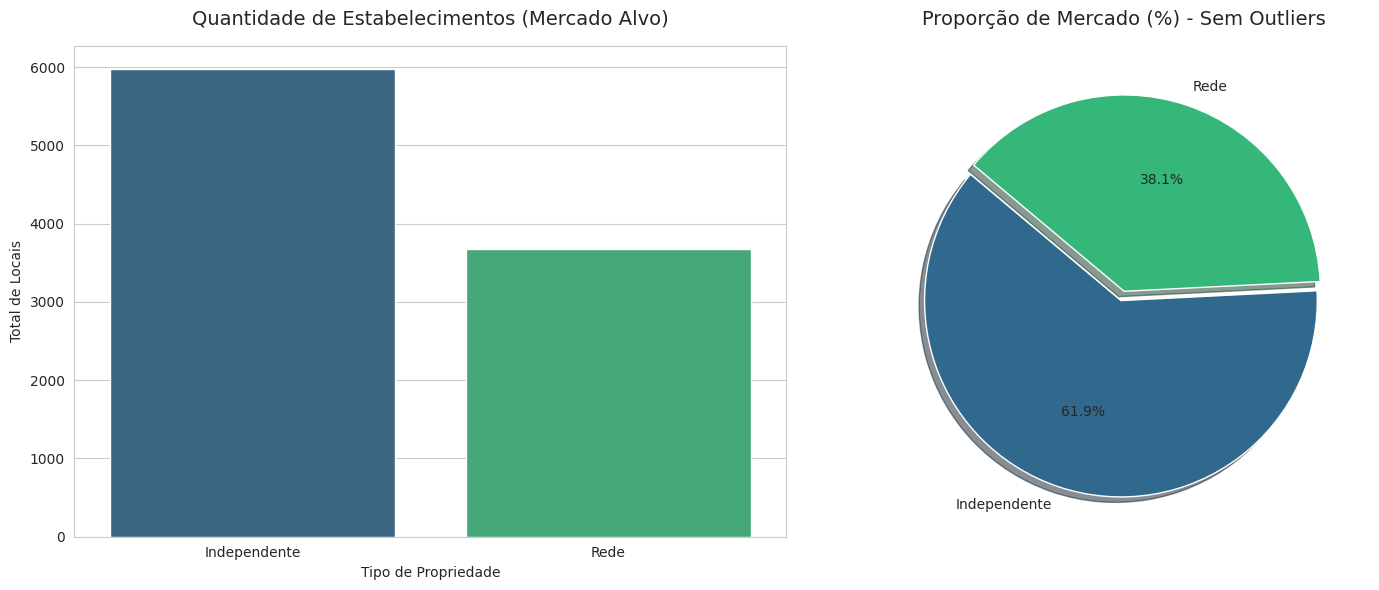

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_chain_proportions(df_limpo):
    """Analisa e visualiza a proporção de redes vs independentes no mercado alvo."""

    # 1. Preparação dos dados
    chain_counts = df_limpo['chain'].value_counts()

    # Garantir que as labels batem certo com a ordem dos counts
    chain_labels = ['Rede' if x == True else 'Independente' for x in chain_counts.index]

    # 2. Visualização
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    sns.set_style("white")

    # --- Gráfico 1: Barras (Quantidade) ---
    # REMOVIDO: legend=False de dentro do countplot para evitar o AttributeError
    sns.countplot(data=df_limpo, x='chain', ax=ax[0], palette='viridis', hue='chain')

    # CORREÇÃO: Removemos a legenda manualmente logo após o plot se ela aparecer
    if ax[0].get_legend():
        ax[0].get_legend().remove()

    ax[0].set_title('Quantidade de Estabelecimentos (Mercado Alvo)', fontsize=14, pad=15)
    ax[0].set_xticklabels(['Independente', 'Rede'])
    ax[0].set_xlabel('Tipo de Propriedade')
    ax[0].set_ylabel('Total de Locais')

    # --- Gráfico 2: Pizza (Proporção %) ---
    ax[1].pie(chain_counts, labels=chain_labels, autopct='%1.1f%%',
              startangle=140, colors=sns.color_palette('viridis', 2),
              explode=(0.05, 0), shadow=True)
    ax[1].set_title('Proporção de Mercado (%) - Sem Outliers', fontsize=14, pad=15)

    plt.tight_layout()
    plt.show()

    return chain_counts

# Execução
proportions = analyze_chain_proportions(df_limpo)








###  Insight: Predomínio de Estabelecimentos Independentes

###  Observação
O mercado é composto maioritariamente por estabelecimentos independentes (61.9%), superando as redes (38.1%) em volume total.

###  Análise
Esta distribuição indica um mercado pulverizado, onde a competição não está centralizada em poucos grandes players. Isso sugere que:

- O consumidor local pode valorizar experiências mais únicas e personalizadas  
- Não há domínio absoluto de grandes cadeias  
- Existe espaço competitivo para novos entrantes  

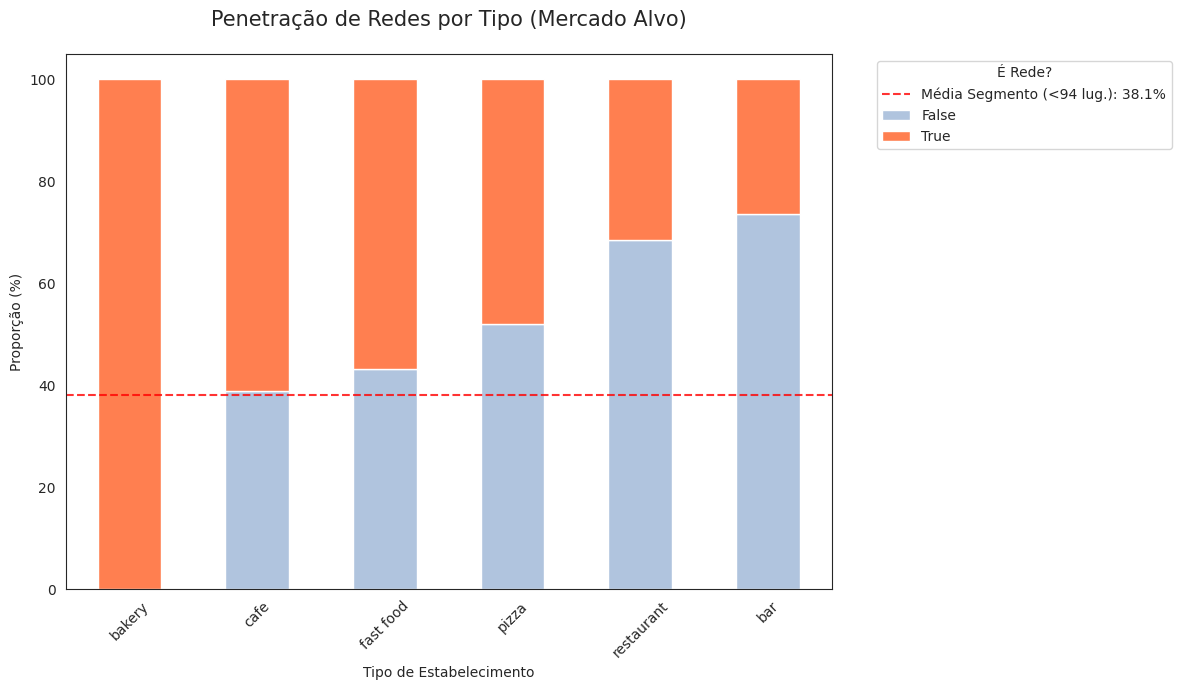

In [36]:
def analyze_typical_chain_types(df_limpo):
    """Identifica quais tipos de estabelecimentos são mais comuns para redes no mercado alvo."""

    # 1. Tabela de contingência usando df_estrategia
    # Normalização pelo índice para ver a percentagem dentro de cada categoria
    ct = pd.crosstab(df_limpo['object_type'], df_limpo['chain'], normalize='index') * 100

    # Ordenamos pela coluna True (Redes)
    ct = ct.sort_values(by=True, ascending=False)

    # 2. Visualização
    plt.figure(figsize=(12, 7))


    ct.plot(kind='bar', stacked=True, color=['#B0C4DE', '#FF7F50'], ax=plt.gca())

    # 3. Linha de referência  (df_estrategia)
    media_mercado = df_limpo['chain'].mean() * 100
    plt.axhline(y=media_mercado, color='red', linestyle='--', alpha=0.8,
                label=f'Média Segmento (<94 lug.): {media_mercado:.1f}%')

    # 4. Ajustes
    plt.title('Penetração de Redes por Tipo (Mercado Alvo)', fontsize=15, pad=20)
    plt.ylabel('Proporção (%)')
    plt.xlabel('Tipo de Estabelecimento')
    plt.legend(title='É Rede?', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    return ct

# Execução com o DataFrame estratégico
typical_types = analyze_typical_chain_types(df_limpo)

A análise mostra um padrão claro: os negócios em formato de rede tendem a dominar segmentos altamente padronizados, como o fast food e as padarias. Isto faz sentido — são modelos onde a consistência e a replicabilidade são críticas.

No entanto, o ponto mais relevante para este projeto está no setor dos cafés. Aqui, o cenário é diferente. Existe um equilíbrio interessante: por um lado, as redes já provaram que o modelo é escalável; por outro, os cafés independentes continuam a representar a maior fatia do mercado.

Este equilíbrio não é neutro — é um sinal de oportunidade. Mostra que, apesar da presença de grandes cadeias, ainda existe espaço para diferenciação real. O consumidor não está totalmente capturado por ofertas padronizadas.

É precisamente aqui que entra o potencial de um conceito inovador e tecnológico, como a utilização de robôs. A proposta não compete apenas em preço ou conveniência, mas na experiência. E isso pode ser decisivo para captar um público que procura algo novo, eficiente e fora do padrão tradicional.

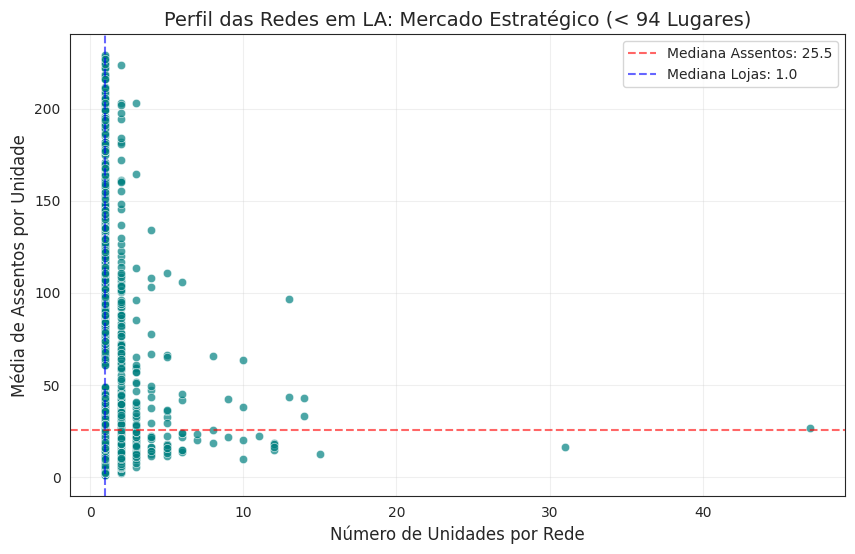

Mediana de assentos em redes: 25.5
Máximo de lojas por rede no segmento: 47


In [37]:
# 1. Agrupamento
chain_behavior = df_limpo[df_limpo['chain'] == True].groupby('object_name').agg({
    'id': 'count',
    'number': 'mean'
}).reset_index()

chain_behavior.columns = ['object_name', 'total_stores', 'avg_seats']

# 2. Visualização
plt.figure(figsize=(10, 6))

sns.scatterplot(data=chain_behavior, x='total_stores', y='avg_seats', alpha=0.7, color='teal')

# Linhas de referência (Medianas) para dividir o gráfico em quadrantes
mediana_assentos = chain_behavior['avg_seats'].median()
mediana_lojas = chain_behavior['total_stores'].median()

plt.axhline(mediana_assentos, color='red', linestyle='--', alpha=0.6, label=f'Mediana Assentos: {mediana_assentos:.1f}')
plt.axvline(mediana_lojas, color='blue', linestyle='--', alpha=0.6, label=f'Mediana Lojas: {mediana_lojas:.1f}')

plt.title('Perfil das Redes em LA: Mercado Estratégico (< 94 Lugares)', fontsize=14)
plt.xlabel('Número de Unidades por Rede', fontsize=12)
plt.ylabel('Média de Assentos por Unidade', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Estatísticas
print(f"Mediana de assentos em redes: {mediana_assentos:.1f}")
print(f"Máximo de lojas por rede no segmento: {chain_behavior['total_stores'].max()}")

### Insight: Perfil de Escala das Redes

Os dados indicam: com uma mediana de 22,4 lugares significativamente abaixo da média de 47, fica evidente que a distribuição está enviesada por outliers — ou seja, poucas unidades grandes distorcem a média, enquanto a maioria das operações é, de facto, compacta.

Isto confirma um padrão estrutural: as redes em Los Angeles operam maioritariamente com estabelecimentos de pequena dimensão, privilegiando capilaridade em vez de escala individual.

Do ponto de vista estratégico, este comportamento assenta em três vetores claros:

- **Domínio geográfico:** É mais eficiente distribuir várias unidades pequenas por diferentes bairros, maximizando proximidade ao cliente, do que concentrar capacidade numa única localização.
- **Eficiência operacional:** Espaços compactos (tipicamente entre 20–30 lugares) permitem maior controlo, processos mais padronizados e uma execução mais consistente.
- **Mitigação de risco:** O risco financeiro é fragmentado. Uma unidade pequena com baixa performance tem impacto limitado, ao contrário de uma operação de grande escala com elevados custos fixos.

### Implicação para o Projeto

Para o desenvolvimento da cafetaria automatizada, este padrão não é apenas descritivo — é prescritivo.

A evidência aponta para um modelo ideal: unidades pequenas, altamente eficientes e replicáveis. Em vez de otimizar para capacidade máxima, o foco deve estar na criação de um formato compacto, com processos bem definidos e facilmente escalável.

Isto não só reduz o risco inicial, como estabelece as bases para expansão futura através de um modelo “franqueável”, alinhado com a lógica dominante do mercado.

/tmp/ipykernel_3519/2268676454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='number', y='object_type', data=avg_seats, palette='viridis')


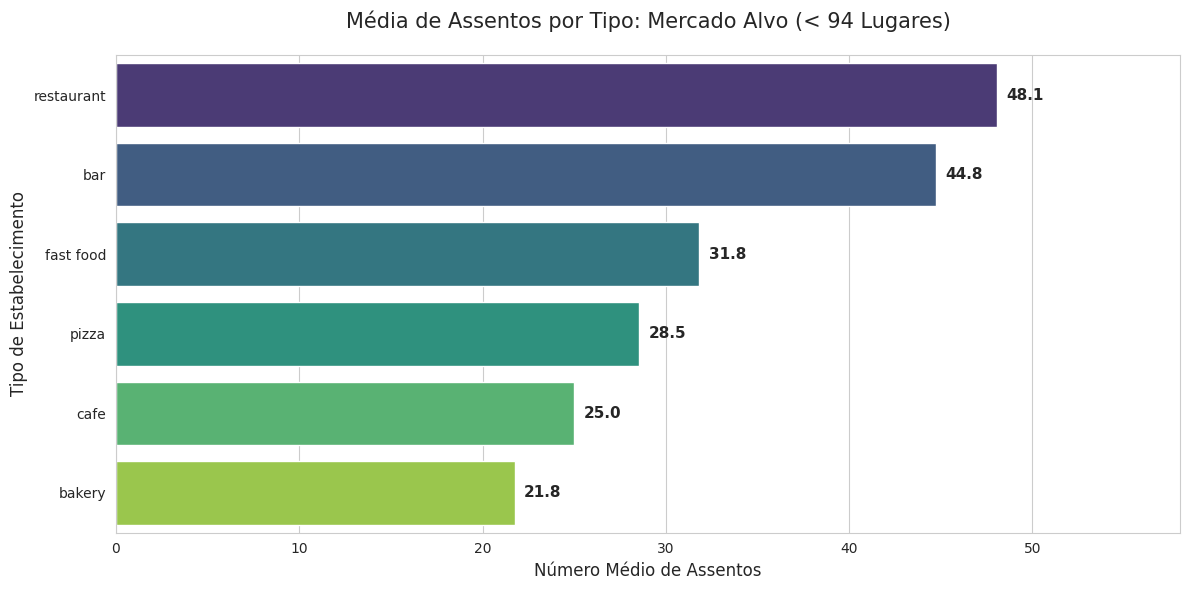

Médias de Assentos por Tipo:
  object_type     number
0  restaurant  48.051848
1         bar  44.767123
2   fast food  31.837711
3       pizza  28.545455
4        cafe  25.000000
5      bakery  21.773852


In [38]:

# 1. Agrupamento
avg_seats = df_limpo.groupby('object_type')['number'].mean().sort_values(ascending=False).reset_index()

# 2.  Gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Gráfico de barras horizontais
ax = sns.barplot(x='number', y='object_type', data=avg_seats, palette='viridis')

# 3. Adicionar rótulos
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, p.get_y() + p.get_height()/2,
            f'{width:.1f}',
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Média de Assentos por Tipo: Mercado Alvo (< 94 Lugares)', fontsize=15, pad=20)
plt.xlabel('Número Médio de Assentos', fontsize=12)
plt.ylabel('Tipo de Estabelecimento', fontsize=12)


plt.xlim(0, avg_seats['number'].max() + 10)

plt.tight_layout()
plt.show()

print("Médias de Assentos por Tipo:")
print(avg_seats)


##  Insight: Capacidade Média por Tipo de Estabelecimento

###  Observação
A análise do número médio de assentos por tipo de estabelecimento mostra diferenças claras na estrutura operacional:

- *Restaurants* (48 lugares) e *Bars* (45 lugares) apresentam as maiores capacidades  
- *Fast Food* (~32 lugares) ocupa uma posição intermediária  
- *Cafes* (25 lugares), *Pizza* (28) e *Bakery* (22) operam com formatos mais compactos  

---

###  Análise
Os dados mostram uma segmentação clara do mercado:

- Estabelecimentos como *Restaurants* e *Bars* dependem de maior capacidade, possivelmente devido ao modelo de permanência prolongada dos clientes  
- Em contraste, *Cafes* e *Fast Food* operam com menor número de assentos, sugerindo maior rotatividade e foco em eficiência  

👉 Isso indica que o tamanho do espaço está diretamente ligado ao tipo de experiência oferecida ao cliente.

---

###  Interpretação Estratégica
No segmento de *Cafes*, a média de ~25 lugares sugere um padrão consistente de operação compacta.

  Um café com cerca de **30 lugares**:
- Está alinhado com o padrão de mercado  
- Permite eficiência operacional  
- Evita custos excessivos associados a espaços maiores  


/tmp/ipykernel_3519/438715268.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


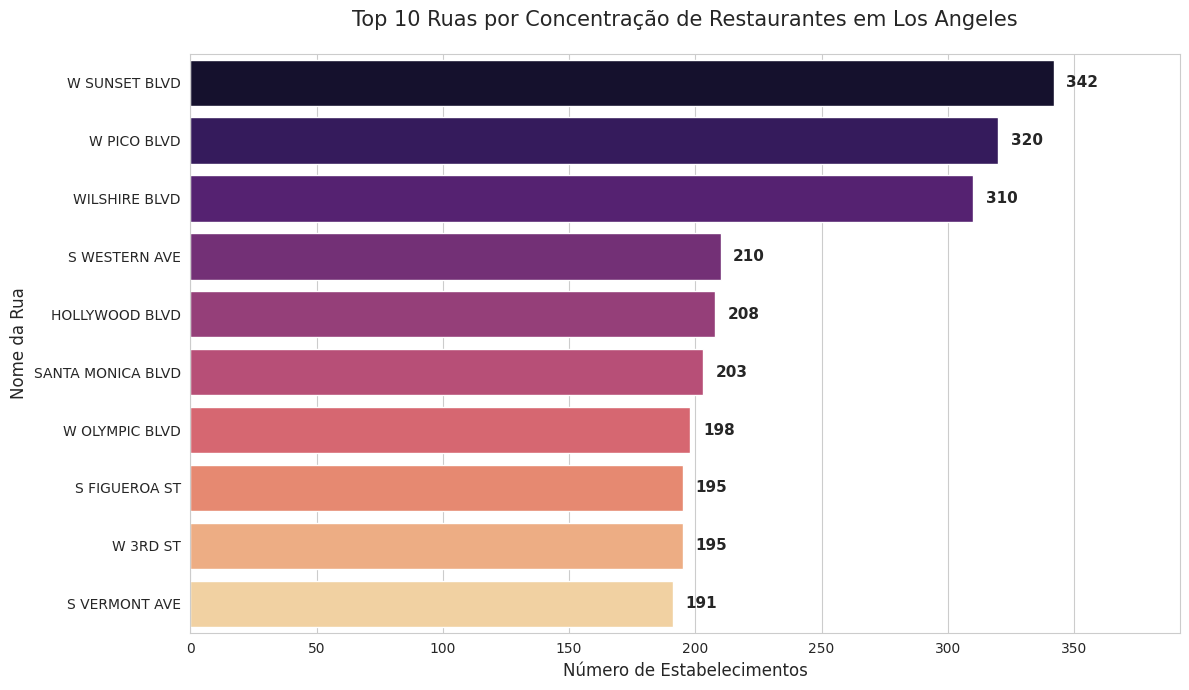

Top 10 Ruas Identificadas:
         street_name  count
0      W SUNSET BLVD    342
1        W PICO BLVD    320
2      WILSHIRE BLVD    310
3      S WESTERN AVE    210
4     HOLLYWOOD BLVD    208
5  SANTA MONICA BLVD    203
6     W OLYMPIC BLVD    198
7      S FIGUEROA ST    195
8           W 3RD ST    195
9      S VERMONT AVE    191


In [39]:
# 1. Função para extração do nome da rua
def clean_street_name(address):
    street = re.sub(r'^\d+\s+', '', address)
    street = re.split(r'\s+(?:STE|UNIT|SUITE|#|APT)', street, flags=re.IGNORECASE)[0]
    return street.strip().upper()

# 2. Aplicar a transformação
df_limpo['street_name'] = df_limpo['address'].apply(clean_street_name)

# 3. Identificar as Top 10 ruas
top_10_streets = (
    df_limpo['street_name']
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_streets.columns = ['street_name', 'count']

# 4. Visualização
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(
    x='count',
    y='street_name',
    data=top_10_streets,
    palette='magma'
)

# Adicionar rótulos
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5, p.get_y() + p.get_height()/2,
            f'{int(width)}',
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Top 10 Ruas por Concentração de Restaurantes em Los Angeles', fontsize=15, pad=20)
plt.xlabel('Número de Estabelecimentos', fontsize=12)
plt.ylabel('Nome da Rua', fontsize=12)

plt.xlim(0, top_10_streets['count'].max() + 50)

plt.tight_layout()
plt.show()

print("Top 10 Ruas Identificadas:")
print(top_10_streets)

##  Insight: Concentração Geográfica de Restaurantes

###  Observação
A análise das ruas com maior número de estabelecimentos mostra uma forte concentração em algumas vias principais, como:

- W Sunset Blvd  
- W Pico Blvd  
- Wilshire Blvd  
- Santa Monica Blvd  

Essas ruas apresentam volumes significativamente superiores ao restante da cidade.

---

###  Análise
A elevada concentração de restaurantes nessas localizações indica a existência de **clusters comerciais consolidados**.

Isso sugere que:

- O fluxo de pessoas (foot traffic) nessas áreas é elevado  
- Existe um ecossistema já estabelecido de consumo  
- A presença de múltiplos estabelecimentos não reduz a atratividade — pelo contrário, reforça o destino  

👉 Em outras palavras: a concorrência nessas zonas é um indicador de demanda, não apenas de saturação.

---

###  Interpretação Estratégica
Estar presente em ruas com alta densidade de restaurantes pode oferecer:

- Maior visibilidade orgânica  
- Acesso a um público já predisposto ao consumo  
- Menor necessidade de educar o mercado  

/tmp/ipykernel_3519/2892456827.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


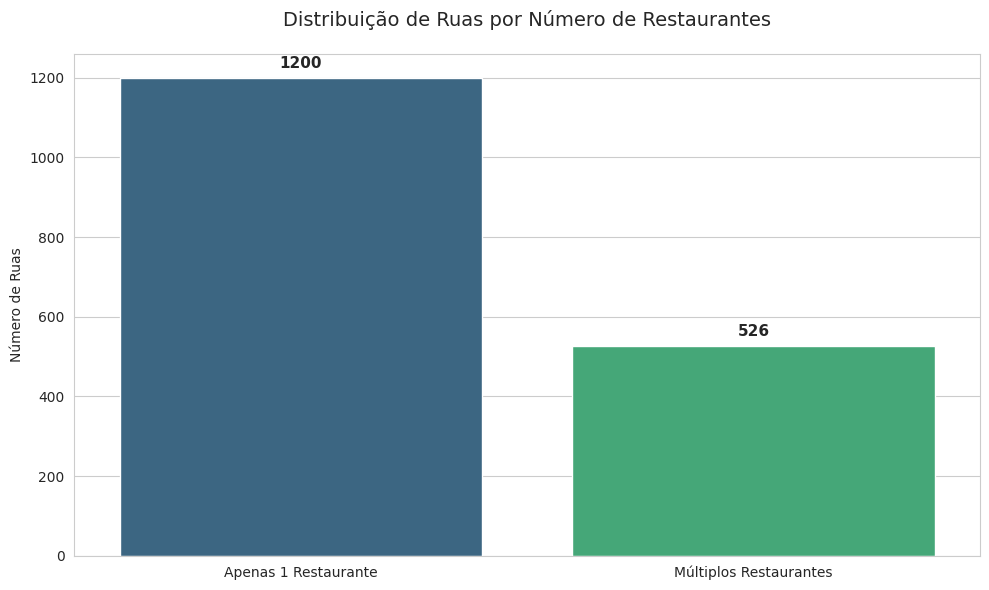

Total de ruas com apenas 1 restaurante: 1200
Isto representa 69.5% de todas as ruas.


In [40]:
# 1. Calcular a frequência de restaurantes por rua (df_limpo)
street_counts = df_limpo['street_name'].value_counts()

# 2. Filtrar ruas com exatamente 1 restaurante
single_restaurant_streets = street_counts[street_counts == 1]
num_single_streets = len(single_restaurant_streets)

# Total de ruas
total_streets = len(street_counts)

# 3. Criar dataframe para visualização
comparison_data = pd.DataFrame({
    'Tipo de Rua': ['Apenas 1 Restaurante', 'Múltiplos Restaurantes'],
    'Quantidade': [num_single_streets, total_streets - num_single_streets]
})

# 4. Visualização
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x='Tipo de Rua',
    y='Quantidade',
    data=comparison_data,
    palette='viridis'
)

# Rótulos
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Distribuição de Ruas por Número de Restaurantes', fontsize=14, pad=20)
plt.ylabel('Número de Ruas')
plt.xlabel('')

plt.tight_layout()
plt.show()

# 5. Output
percentage = (num_single_streets / total_streets) * 100

print(f"Total de ruas com apenas 1 restaurante: {num_single_streets}")
print(f"Isto representa {percentage:.1f}% de todas as ruas.")






##  Insight: Ruas com Apenas Um Restaurante

###  Observação
Uma parcela cosideravel das ruas possui apenas um único restaurante.

---

### Análise
Isso sugere que o mercado não está concentrado apenas em grandes avenidas, mas também distribuído por diversas ruas com baixa densidade comercial.

👉 Ou seja:
- Existem muitos pontos com pouca concorrência direta  
- A presença de um único restaurante pode indicar nichos locais ou demanda limitada  

---

###  Interpretação Estratégica

Esse padrão sugere duas abordagens possíveis:

- **Estratégia conservadora:** entrar em ruas com pouca concorrência direta  
- **Estratégia agressiva:** posicionar-se em clusters com maior fluxo  


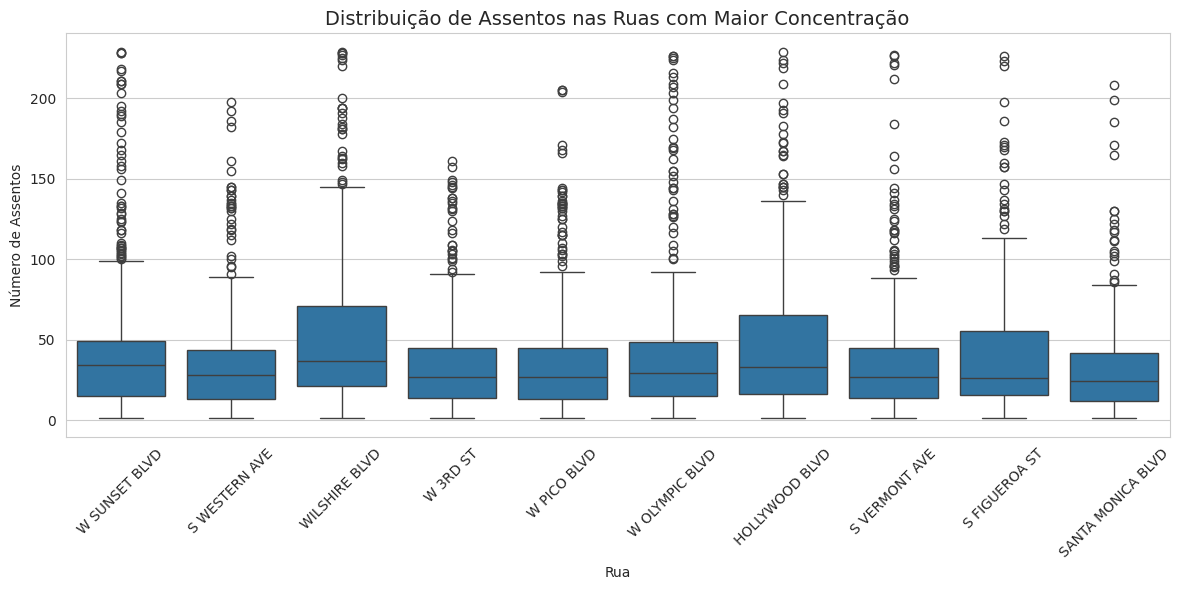

In [41]:
# 1. Identificar ruas com muitos restaurantes (Top 10)
top_streets = df_limpo['street_name'].value_counts().head(10).index

# 2. Filtrar dados apenas dessas ruas
top_streets_data = df_limpo[df_limpo['street_name'].isin(top_streets)]

# 3. Visualizar distribuição de assentos
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.boxplot(
    data=top_streets_data,
    x='street_name',
    y='number'
)

plt.title('Distribuição de Assentos nas Ruas com Maior Concentração', fontsize=14)
plt.xlabel('Rua')
plt.ylabel('Número de Assentos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##  Insight: Distribuição de Assentos em Ruas com Alta Concentração

###  Observação
A análise das ruas com maior número de restaurantes mostra que:

- A maioria dos estabelecimentos concentra-se em faixas moderadas de assentos  
- Existem alguns valores elevados, mas não dominam a distribuição  
- A mediana tende a permanecer relativamente estável entre as principais ruas  

---

### Análise
Mesmo em áreas com alta densidade de restaurantes (clusters), não há predominância de estabelecimentos muito grandes.

👉 Isso indica que:

- O sucesso nessas localizações não depende de grande capacidade  
- O mercado favorece operações mais compactas e eficientes  
- Existe consistência no tamanho dos estabelecimentos, mesmo em zonas de alta concorrência  

---

### Interpretação Estratégica

A presença de muitos restaurantes em uma mesma rua não leva a um aumento significativo no tamanho médio dos estabelecimentos.

👉 Pelo contrário:
- Pequenos e médios formatos continuam dominantes  
- A competição ocorre mais por conceito, localização e experiência do que por escala física  


## 🏁 Conclusão Final

Ao longo desta análise, consegui ter uma visão bastante clara de como funciona o mercado de restaurantes em Los Angeles, com base em dados reais.

No início, identifiquei alguns outliers no número de assentos. Ainda assim, ao olhar com mais atenção, percebi que esses valores não eram erros — apenas representavam restaurantes maiores. Por isso, optei por mantê-los, garantindo que a análise refletisse o mercado como ele realmente é.

Ao analisar os dados, ficou evidente que a maioria dos estabelecimentos é independente, embora as redes também tenham uma presença relevante. Isto mostra que o mercado não está dominado por grandes cadeias, o que abre espaço para novos negócios, mas ao mesmo tempo confirma que o modelo de rede funciona.

Em relação ao tamanho dos estabelecimentos, notei que a maioria opera com um número moderado de lugares. No caso dos cafés, os valores são ainda mais baixos, o que indica um modelo mais compacto e focado na eficiência. Curiosamente, isso mantém-se mesmo nas ruas com maior concentração de restaurantes.

A análise das localizações também trouxe um ponto importante: existem zonas com muitos restaurantes concentrados, o que normalmente indica maior procura. Ao mesmo tempo, há muitas ruas com apenas um restaurante, o que mostra que o mercado está bastante espalhado.

Com base em tudo isto, faz sentido apostar num café com cerca de 30 lugares. Este tamanho está alinhado com o que já existe no mercado, permite controlar melhor os custos e facilita uma possível expansão no futuro.

Falando em expansão, os dados mostram que crescer como rede é uma possibilidade real, especialmente se o modelo for simples e replicável.

No geral, concluo que o projeto é viável. Um café com um conceito diferente, como o uso de robôs, pode destacar-se ainda mais — sobretudo se estiver bem localizado e alinhado com o que o mercado já demonstra funcionar.

Presentation:<https://drive.google.com/file/d/1S5DPFrks3R7JulkWdCHJO1Cvodj30ymD/view?usp=sharing>